<a href="https://colab.research.google.com/github/jtGHub-svg/Fase5_Datathon/blob/main/Fase_5_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bibliotecas
import os, re, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
import pandas as pd
import numpy as np
import re
import joblib
from datetime import datetime
import unicodedata
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, lit, isnan, sum, round, avg
from pyspark.sql import functions as F
from pyspark.sql import Window

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.utils import resample
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer


In [2]:
# Criar sessão Spark
spark = SparkSession.builder.appName("Desenvolvimento_Educacional").getOrCreate()

In [3]:
# Variáveis

#Caminho do arquivo excel
excel_file = "/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"


In [4]:
# Transforma as abas do excel em arquivos csv

# Ler todas as abas
sheets = pd.read_excel(excel_file, sheet_name=None)

# Salvar cada aba como CSV
for sheet_name, df in sheets.items():
    # Cria um nome de arquivo CSV baseado no nome da aba
    csv_file_name = f"{sheet_name}.csv"

    # Salva o DataFrame como CSV
    # index=False evita salvar a coluna de índices do Pandas
    df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')
    print(f"Aba '{sheet_name}' salva como: {csv_file_name}")

Aba 'PEDE2022' salva como: PEDE2022.csv
Aba 'PEDE2023' salva como: PEDE2023.csv
Aba 'PEDE2024' salva como: PEDE2024.csv


In [5]:
# Ler os arquivos csv gerado
df_PEDE2022 = spark.read.csv("PEDE2022.csv", sep=",", header=True, inferSchema=True)
df_PEDE2023 = spark.read.csv("PEDE2023.csv", sep=",", header=True, inferSchema=True)
df_PEDE2024 = spark.read.csv("PEDE2024.csv", sep=",", header=True, inferSchema=True)

In [6]:
# Linhas e colunas PEDE2022
print('\nLinhas e colunas PEDE2022')
print('Linhas: ', df_PEDE2022.count())
print('Colunas: ', len(df_PEDE2022.columns))

# Linhas e colunas PEDE2023
print('\nLinhas e colunas PEDE2023')
print('Linhas: ', df_PEDE2023.count())
print('Colunas: ', len(df_PEDE2023.columns))

# Linhas e colunas PEDE2024
print('\nLinhas e colunas PEDE2024')
print('Linhas: ', df_PEDE2024.count())
print('Colunas: ', len(df_PEDE2024.columns))


Linhas e colunas PEDE2022
Linhas:  860
Colunas:  42

Linhas e colunas PEDE2023
Linhas:  1014
Colunas:  48

Linhas e colunas PEDE2024
Linhas:  1156
Colunas:  50


In [7]:
# Verificação de Nomes, Ordem e Tipos de Dados

# Mostra esquema
df_PEDE2022.printSchema()

# Mostra primeiras linhas
df_PEDE2022.show(5)

root
 |-- RA: string (nullable = true)
 |-- Fase: integer (nullable = true)
 |-- Turma: string (nullable = true)
 |-- Nome: string (nullable = true)
 |-- Ano nasc: integer (nullable = true)
 |-- Idade 22: integer (nullable = true)
 |-- Gênero: string (nullable = true)
 |-- Ano ingresso: integer (nullable = true)
 |-- Instituição de ensino: string (nullable = true)
 |-- Pedra 20: string (nullable = true)
 |-- Pedra 21: string (nullable = true)
 |-- Pedra 22: string (nullable = true)
 |-- INDE 22: double (nullable = true)
 |-- Cg: integer (nullable = true)
 |-- Cf: integer (nullable = true)
 |-- Ct: integer (nullable = true)
 |-- Nº Av: integer (nullable = true)
 |-- Avaliador1: string (nullable = true)
 |-- Rec Av1: string (nullable = true)
 |-- Avaliador2: string (nullable = true)
 |-- Rec Av2: string (nullable = true)
 |-- Avaliador3: string (nullable = true)
 |-- Rec Av3: string (nullable = true)
 |-- Avaliador4: string (nullable = true)
 |-- Rec Av4: string (nullable = true)
 |-- IA

In [8]:
# Mostra esquema
df_PEDE2023.printSchema()

# Mostra primeiras linhas
df_PEDE2023.show(5)

root
 |-- RA: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- INDE 2023: double (nullable = true)
 |-- Pedra 2023: string (nullable = true)
 |-- Turma: string (nullable = true)
 |-- Nome Anonimizado: string (nullable = true)
 |-- Data de Nasc: string (nullable = true)
 |-- Idade: string (nullable = true)
 |-- Gênero: string (nullable = true)
 |-- Ano ingresso: integer (nullable = true)
 |-- Instituição de ensino: string (nullable = true)
 |-- Pedra 20: string (nullable = true)
 |-- Pedra 21: string (nullable = true)
 |-- Pedra 22: string (nullable = true)
 |-- Pedra 23: string (nullable = true)
 |-- INDE 22: double (nullable = true)
 |-- INDE 23: string (nullable = true)
 |-- Cg: string (nullable = true)
 |-- Cf: string (nullable = true)
 |-- Ct: string (nullable = true)
 |-- Nº Av: double (nullable = true)
 |-- Avaliador1: string (nullable = true)
 |-- Rec Av1: string (nullable = true)
 |-- Avaliador2: string (nullable = true)
 |-- Rec Av2: string (nullable = true)
 

In [9]:
# Mostra esquema
df_PEDE2024.printSchema()

# Mostra primeiras linhas
df_PEDE2024.show(5)

root
 |-- RA: string (nullable = true)
 |-- Fase: string (nullable = true)
 |-- INDE 2024: string (nullable = true)
 |-- Pedra 2024: string (nullable = true)
 |-- Turma: string (nullable = true)
 |-- Nome Anonimizado: string (nullable = true)
 |-- Data de Nasc: timestamp (nullable = true)
 |-- Idade: integer (nullable = true)
 |-- Gênero: string (nullable = true)
 |-- Ano ingresso: integer (nullable = true)
 |-- Instituição de ensino: string (nullable = true)
 |-- Pedra 20: string (nullable = true)
 |-- Pedra 21: string (nullable = true)
 |-- Pedra 22: string (nullable = true)
 |-- Pedra 23: string (nullable = true)
 |-- INDE 22: double (nullable = true)
 |-- INDE 23: double (nullable = true)
 |-- Cg: string (nullable = true)
 |-- Cf: string (nullable = true)
 |-- Ct: string (nullable = true)
 |-- Nº Av: integer (nullable = true)
 |-- Avaliador1: string (nullable = true)
 |-- Rec Av1: string (nullable = true)
 |-- Avaliador2: string (nullable = true)
 |-- Rec Av2: string (nullable = tr

In [10]:
"""
Limpeza e consolidação dos arquivos PEDE 2022–2024
Regras aplicadas:
 1) Inclui Ano_Dados
 2) Remove Pedra 20 e Pedra 21 (todos anos)
 3) Remove Pedra 22, Pedra 23, INDE 22, INDE 23 (apenas 2023 e 2024)
 4) Remove Destaque IPV.1 (2023)
 5) Remove Avaliador5, Avaliador6, Escola, Ativo/ Inativo e Ativo/ Inativo.1 (2024)
 6) Padroniza nomes de colunas (substitui espaços/pontos/“º” por _ e remove sufixos de anos)
 7) Em 2023 recalcula Idade = 2023 - ano(Data de Nasc)
 8) Renomeia "Nome Anonimizado" → "Nome"
 9) Padroniza nomes de campos para todos os anos
10) Converte strings numéricas para numérico quando fizer sentido
11) Padroniza Fase (ALFA→0; “Fase n (…)”→n; “nA..nX”→n)
"""

# ---------- utilitários ----------
def carregar_csv(nome_arquivo: str) -> pd.DataFrame:
    try:
        return pd.read_csv(nome_arquivo, dtype=str, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(nome_arquivo, dtype=str, encoding="latin-1")

def limpar_nome_coluna(col: str) -> str:
    s = col.replace("º", "").replace(".", "").replace(" ", "_")
    s = s.replace("/", "_").replace("-", "_")
    s = re.sub(r"_+", "_", s)
    s = re.sub(r"_(19|20)\d{2}$", "", s)  # remove sufixo _YYYY
    s = re.sub(r"_\d{2}$", "", s)         # remove sufixo _YY
    return s.strip("_")

def padronizar_fase(valor):
    if pd.isna(valor):
        return None
    v = str(valor).strip().upper()
    if v == "ALFA":
        return 0
    m = re.search(r"FASE\s*(\d+)", v)
    if m:
        return int(m.group(1))
    m2 = re.match(r"^(\d+)[A-Z]+$", v)
    if m2:
        return int(m2.group(1))
    try:
        return int(float(v))
    except ValueError:
        return None


def padronizar_fase_ideal(valor):
    """
    Converte entradas como:
        'Fase 8 (Universitários)', 'Fase 4 (9º ano)', 'Fase 5 (1º EM)', ...
    no inteiro correspondente à fase (8, 4, 5, ...).

    Regras:
    - Ignora maiúsculas/minúsculas, acentos e qualquer texto entre/fora de parênteses.
    - Procura o primeiro número arábico após 'Fase'.
    - Retorna np.nan se não conseguir extrair um número de fase.

    Exemplos:
        'Fase 8 (Universitários)' -> 8
        'Fase 3 (7º e 8º ano)'    -> 3
        '  FASE   5  (1º EM)  '   -> 5
    """
    if pd.isna(valor):

        return np.nan

    s = str(valor).strip()

    # Regex:
    # - (?i)  -> case-insensitive
    # - fase  -> a palavra 'fase' (qualquer caixa)
    # - \s*   -> espaços opcionais
    # - (\d+) -> captura o primeiro grupo de dígitos
    m = re.search(r'(?i)fase\s*(\d+)', s)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            return np.nan
    return np.nan


def padronizar_genero(valor):
    if pd.isna(valor):
        return None
    v = str(valor).strip().upper()
    if v == "MENINA":
        return 'Feminino'
    if v == "MENINO":
        return 'Masculino'
    try:
        return int(float(v))
    except ValueError:
        return None

def forcar_numericos(df: pd.DataFrame) -> pd.DataFrame:
    candidatos_forcados = {
        "IAA","IEG","IPS","IPP","IDA","IAN","IPV","INDE","Cg","Cf","Ct",
        "Mat","Por","Ing","Defasagem","N_Av","Ano_ingresso","Ano_nasc","Idade",
        "INDE_2022","INDE_2023","INDE_2024"
    }
    novos = {}
    for col in df.columns:
        # Mantém categóricas como texto
        if col in {
            "RA","Turma","Nome","Nome_Anonimizado","Genero","Instituicao_de_ensino",
            "Pedra","Pedra_20","Pedra_21","Pedra_22","Pedra_23","Avaliador1","Avaliador2",
            "Avaliador3","Avaliador4","Avaliador5","Avaliador6","Rec_Av1","Rec_Av2",
            "Rec_Av3","Rec_Av4","Rec_Psicologia","Indicado","Destaque_IEG",
            "Destaque_IDA","Destaque_IPV","Escola","Ativo_Inativo","Ativo_Inativo_1"
        }:
            # Substitui os dados com a palavra incluir por nulo
            df[col] = df[col].replace('INCLUIR', pd.NA)
            continue
        serie = df[col]
        if serie.dtype == object:
            s = serie.str.replace(",", ".", regex=False)
            num = pd.to_numeric(s, errors="coerce")
            non_na = num.notna().sum()
            orig_non_na = serie.notna().sum()
            proporcao = (non_na / orig_non_na) if orig_non_na else 0
            if proporcao >= 0.8 or col in candidatos_forcados or re.search(r"(\d)", col):
                novos[col] = num
    if novos:
        df = df.assign(**novos)
    return df

# Padronizar campo datas de nascimento
def padronizar_data_nascimento(series: pd.Series):
    def parse_one(x):
        if pd.isna(x): return None
        s = str(x).strip()
        if not s: return None
        s = re.sub(r"\s+\d{2}:\d{2}:\d{2}$", "", s)
        for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%Y/%m/%d"):
            try: return datetime.strptime(s, fmt).date()
            except ValueError: pass
        m = re.match(r"^(\d{4})", s)
        if m: return datetime(int(m.group(1)), 1, 1).date()
        return None
    return series.apply(parse_one)

# processar arquivos csv gerados
def processar(arquivo: str, ano_dados: int) -> pd.DataFrame:
    df = carregar_csv(arquivo)
    # 1) Ano_Dados
    df["Ano_Dados"] = str(ano_dados)

    # Remove as colunas Pedra 20 e 21
    for c in ["Pedra 20","Pedra 21"]:
        if c in df.columns:
            df = df.drop(columns=[c])

    # Remove as colunas Pedra 22, Pedra 23, INDE 22 e INDE 23 (2023/2024)
    if ano_dados in (2023, 2024):
        for c in ["Pedra 22","Pedra 23","INDE 22","INDE 23"]:
            if c in df.columns:
                df = df.drop(columns=[c])

    # Remove a coluna Destaque IPV.1 (2023)
    if ano_dados == 2023 and "Destaque IPV.1" in df.columns:
        df = df.drop(columns=["Destaque IPV.1"])

    # Remove colunas Avaliador5, Avaliador6, Escola, Ativo/ Inativo e Ativo/ Inativo.1 (2024)
    if ano_dados == 2024:
        for c in ["Avaliador5","Avaliador6","Escola","Ativo/ Inativo","Ativo/ Inativo.1"]:
            if c in df.columns:
                df = df.drop(columns=[c])

    # Altera o campo Nome Anonimizado para Nome e ajustes de acentuação
    renomes = {}
    if "Nome Anonimizado" in df.columns:
        renomes["Nome Anonimizado"] = "Nome"
    if "Gênero" in df.columns:
        renomes["Gênero"] = "Genero"
    if "Instituição de ensino" in df.columns:
        renomes["Instituição de ensino"] = "Instituicao de ensino"
    if "Data de Nasc" in df.columns:
        renomes["Data de Nasc"] = "Data de Nasc"
    if renomes:
        df = df.rename(columns=renomes)

    # Padroniza cabeçalho
    df = df.rename(columns={c: limpar_nome_coluna(c) for c in df.columns})

    # Calcula Idade 2023 a partir de Data_de_Nasc e
    # calcula o ano de nascimento dos anos 2022 e 2024 a partir data
    # de nascimento e deleta campo data de nascimento
    ano_nasc_series = pd.Series([None]*len(df))
    if "Data_de_Nasc" in df.columns:
        parsed = padronizar_data_nascimento(df["Data_de_Nasc"])
        ano_nasc_series = parsed.apply(lambda d: d.year if d else None)
        if ano_dados == 2023:
            df["Idade"] = parsed.apply(lambda d: 2023 - d.year if d else None)
        df = df.drop(columns=["Data_de_Nasc"])
    else:
        if "Ano_nasc" in df.columns:
            ano_nasc_series = pd.to_numeric(df["Ano_nasc"], errors="coerce")
        elif "Idade" in df.columns and df["Idade"].notna().any():
            idade_num = pd.to_numeric(df["Idade"], errors="coerce")
            ano_ref = int(df["Ano_Dados"].iloc[0])
            ano_nasc_series = ano_ref - idade_num
    df["Ano_nasc"] = ano_nasc_series

    # Fase
    if "Fase" in df.columns:
        df["Fase"] = df["Fase"].apply(padronizar_fase)

    # Fase Ideal
    if "Fase_ideal" in df.columns:
        df["Fase_ideal"] = df["Fase_ideal"].apply(padronizar_fase_ideal)

    # Gênero
    if "Genero" in df.columns:
        df["Genero"] = df["Genero"].apply(padronizar_genero)

    # Forçar numéricos
    df = forcar_numericos(df)

    return df

# ---------- executa para 2022, 2023, 2024 ----------
arquivos = [("PEDE2022.csv", 2022), ("PEDE2023.csv", 2023), ("PEDE2024.csv", 2024)]
processados = {}
for nome, ano in arquivos:
    processados[ano] = processar(nome, ano)

# Harmonização final dos nomes (sinônimos)
CANONICOS = {
    "Matem": "Mat",
    "Portug": "Por",
    "Ingles": "Ing",     # caso sem acento
    "Inglês": "Ing",     # caso com acento
    "Fase_ideal": "Fase_Ideal",
    "Defas": "Defasagem",
}
for ano, df in processados.items():
    processados[ano] = df.rename(columns={c: CANONICOS.get(c, c) for c in df.columns})

# Ordem final das colunas (idêntica nos três arquivos)
todas = set()
for df in processados.values():
    todas.update(df.columns)
base_ordem = [
    "RA","Nome","Fase","Turma","Ano_Dados","Ano_nasc","Idade","Genero",
    "Ano_ingresso","Instituicao_de_ensino","Pedra","INDE","Cg","Cf","Ct","N_Av",
    "Avaliador1","Rec_Av1","Avaliador2","Rec_Av2","Avaliador3","Rec_Av3","Avaliador4","Rec_Av4",
    "IAA","IEG","IPS","IPP","Rec_Psicologia","IDA","Mat","Por","Ing","Indicado","Atingiu_PV",
    "IPV","IAN","Fase_Ideal","Defasagem","Destaque_IEG","Destaque_IDA","Destaque_IPV"
]
ordem = [c for c in base_ordem if c in todas] + sorted([c for c in todas if c not in base_ordem])

# Salva 3 arquivos limpos
for ano, df in processados.items():
    df = df.reindex(columns=ordem)
    df.to_csv(f"PEDE{ano}_limpo.csv", index=False, encoding="utf-8-sig")

# Consolida (concatena) os três anos
dfs = [processados[2022].reindex(columns=ordem),
       processados[2023].reindex(columns=ordem),
       processados[2024].reindex(columns=ordem)]
consolidado = pd.concat(dfs, ignore_index=True).sort_values(["Ano_Dados","RA"], ignore_index=True)

# Exporta consolidado
consolidado.to_csv("PEDE_consolidado_2022_2024.csv", index=False, encoding="utf-8-sig")

print("Concluído!")

Concluído!


In [11]:
# Ler o arquivo consolidado
df_consolidado = spark.read.csv("PEDE_consolidado_2022_2024.csv", sep=",", header=True, inferSchema=True)

# Mostra esquema
df_consolidado.printSchema()

# Mostra primeiras linhas
df_consolidado.show(5)
df_consolidado.orderBy("Ano_Dados", ascending=False).show(5)

root
 |-- RA: string (nullable = true)
 |-- Nome: string (nullable = true)
 |-- Fase: integer (nullable = true)
 |-- Turma: string (nullable = true)
 |-- Ano_Dados: integer (nullable = true)
 |-- Ano_nasc: integer (nullable = true)
 |-- Idade: integer (nullable = true)
 |-- Genero: string (nullable = true)
 |-- Ano_ingresso: integer (nullable = true)
 |-- Instituicao_de_ensino: string (nullable = true)
 |-- Pedra: string (nullable = true)
 |-- INDE: double (nullable = true)
 |-- Cg: double (nullable = true)
 |-- Cf: double (nullable = true)
 |-- Ct: double (nullable = true)
 |-- N_Av: double (nullable = true)
 |-- Avaliador1: string (nullable = true)
 |-- Rec_Av1: string (nullable = true)
 |-- Avaliador2: string (nullable = true)
 |-- Rec_Av2: string (nullable = true)
 |-- Avaliador3: string (nullable = true)
 |-- Rec_Av3: string (nullable = true)
 |-- Avaliador4: string (nullable = true)
 |-- Rec_Av4: string (nullable = true)
 |-- IAA: double (nullable = true)
 |-- IEG: double (nullab

In [12]:
# Linhas e colunas df_consolidado
print('\nLinhas e colunas df_consolidado')
print('Linhas: ', df_consolidado.count())
print('Colunas: ', len(df_consolidado.columns))


Linhas e colunas df_consolidado
Linhas:  3030
Colunas:  42


In [13]:
# Regras de PEDRA (faixas por INDE), segundo dicionário PEDE
# Quartzo – 2,405 a 5,506 | Ágata – 5,506 a 6,868 | Ametista – 6,868 a 8,230 | Topázio – 8,230 a 9,294
PEDRA_INTERVALOS = [
    ('Quartzo', 2.405, 5.506),
    ('Ágata', 5.506, 6.868),
    ('Ametista', 6.868, 8.230),
    ('Topázio', 8.230, 9.294),
]

In [14]:
# Verificação de valores distintos (duplicidade)
print(f'Quantidade de Linhas: {df_consolidado.count()}')
print(f'Linhas distintas: {df_consolidado.distinct().count()}')

Quantidade de Linhas: 3030
Linhas distintas: 3030


In [15]:
# Estatísticas descritivas
df_consolidado.describe().show()

+-------+------+---------+------------------+-----------------+------------------+------------------+------------------+---------+------------------+---------------------+-----+------------------+------------------+-----------------+-----------------+------------------+------------+--------------------+-----------+--------------------+-----------+--------------------+-----------+--------------------+------------------+-----------------+------------------+-----------------+--------------+------------------+------------------+------------------+-----------------+--------+----------+-----------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+
|summary|    RA|     Nome|              Fase|            Turma|         Ano_Dados|          Ano_nasc|             Idade|   Genero|      Ano_ingresso|Instituicao_de_ensino|Pedra|              INDE|                Cg|               Cf|               Ct|              N_Av|  

In [16]:
df_consolidado.summary().show()  # count, mean, stddev, min, 25%, 50%, 75%, max

# Seleção customizada
df_consolidado.summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

+-------+------+---------+------------------+-----------------+------------------+------------------+------------------+---------+------------------+---------------------+-----+------------------+------------------+-----------------+-----------------+------------------+------------+--------------------+-----------+--------------------+-----------+--------------------+-----------+--------------------+------------------+-----------------+------------------+-----------------+--------------+------------------+------------------+------------------+-----------------+--------+----------+-----------------+------------------+--------------------+------------------+--------------------+--------------------+--------------------+
|summary|    RA|     Nome|              Fase|            Turma|         Ano_Dados|          Ano_nasc|             Idade|   Genero|      Ano_ingresso|Instituicao_de_ensino|Pedra|              INDE|                Cg|               Cf|               Ct|              N_Av|  

In [17]:
# Lê o CSV a partir do Pandas
df_consolidadopd = pd.read_csv("PEDE_consolidado_2022_2024.csv")

# Transforma em excel
df_consolidadopd.to_excel("PEDE_consolidado_2022_2024.xlsx", index=False)

print(f'Quantidade de registros: {len(df_consolidadopd)}')

Quantidade de registros: 3030


Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

In [18]:
# Padroniza os campos em maiúsculas
def padronizar_colunas(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

df_consolidadopd = padronizar_colunas(df_consolidadopd)

In [19]:
# Definição das features

# Ordene por RA e ANO_DADOS
df_ord = df_consolidadopd.sort_values(["RA", "ANO_DADOS"]).copy()

# Selecionar apenas indicadores relevantes
features = ["IAA", "IEG", "IPS", "IDA", "IPP", "IPV", "IAN"]

df_model = df_ord[["RA", "ANO_DADOS", "DEFASAGEM"] + features].copy()

# Criar variável alvo: 1 = risco, 0 = sem risco
df_model["RISCO_DEFASAGEM"] = (
    df_model.groupby("RA")["DEFASAGEM"]
            .shift(-1)
            .lt(0)            # equivalente a < 0
            .astype(int)
)


# Remover linhas com valores ausentes
df_model = df_model.dropna()

# Remova apenas linhas que ficaram sem alvo (últimas por RA)
df_model = df_model.dropna(subset=["RISCO_DEFASAGEM"])


X = df_model[features]
y = df_model["RISCO_DEFASAGEM"]

In [20]:
# Treinamento do modelo preditivo

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Peso da classe positiva p/ XGBoost (quando há desbalanceamento)
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0


# Modelos
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.5,
            class_weight="balanced",
            max_iter=1000,
            solver="liblinear"
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),


    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="auc"  # foca em AUC
    ),

    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=2,
            gamma="scale",
            kernel="rbf",
            probability=True
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=15,
            weights="distance"
        ))
    ])
}


# Predições
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        "accuracy": acc,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

    print(f"\n{name} Accuracy: {acc:.2%}")
    print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 69.97%
              precision    recall  f1-score   support

           0       0.93      0.70      0.80       504
           1       0.30      0.72      0.42        92

    accuracy                           0.70       596
   macro avg       0.62      0.71      0.61       596
weighted avg       0.83      0.70      0.74       596


Random Forest Accuracy: 82.05%
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       504
           1       0.45      0.74      0.56        92

    accuracy                           0.82       596
   macro avg       0.70      0.79      0.72       596
weighted avg       0.87      0.82      0.84       596


Gradient Boosting Accuracy: 85.74%
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       504
           1       0.57      0.33      0.41        92

    accuracy                           0.86       596
   macro avg       0.7

In [21]:
# Calcula AUC para cada modelo (se tiver predict_proba; senão, use decision_function)
aucs = {}
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # alguns modelos (ex.: SVM com probability=False) têm decision_function
        y_score = model.decision_function(X_test)
    aucs[name] = roc_auc_score(y_test, y_score)

melhor_modelo = max(aucs, key=aucs.get)
modelo_final = models[melhor_modelo]

# Guarde também as probabilidades para uso posterior (ROC, PR, ranking de risco etc.)
if hasattr(modelo_final, "predict_proba"):
    y_proba = modelo_final.predict_proba(X_test)[:, 1]
else:
    y_proba = modelo_final.decision_function(X_test)

y_pred_final = modelo_final.predict(X_test)

print("Melhor (AUC):", melhor_modelo, f"{aucs[melhor_modelo]:.3f}")
print(modelo_final)


os.makedirs("model", exist_ok=True)

joblib.dump(modelo_final, "model/modelo_risco_defasagem.pkl")


Melhor (AUC): Gradient Boosting 0.899
GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)


['model/modelo_risco_defasagem.pkl']

In [22]:
# Função recuperar os nomes
def recupera_nome_depois_process(pipeline, X_reference=None, preprocess_name='preprocess'):
    """
    Retorna os nomes das features após o pré-processamento do pipeline.
    - Tenta pipeline[:-1].get_feature_names_out() quando o último passo é estimador.
    - Ou pipeline.named_steps[preprocess_name].get_feature_names_out() se existir.
    - Ou encontra o primeiro ColumnTransformer dentro dos steps.
    - Se não houver transformações, devolve as colunas de X_reference (se for DataFrame)
      ou índices '0..n-1'.
    """
    # Se for Pipeline e último passo não é transformador, usar até o penúltimo
    if isinstance(pipeline, Pipeline):
        last_step = pipeline.steps[-1][1]
        # Se o último passo não expõe get_feature_names_out, tente até o penúltimo
        if not hasattr(last_step, "get_feature_names_out"):
            try:
                return pipeline[:-1].get_feature_names_out()
            except Exception:
                pass

        # Se tiver um passo nomeado 'preprocess'
        if preprocess_name in pipeline.named_steps:
            pre = pipeline.named_steps[preprocess_name]
            if hasattr(pre, "get_feature_names_out"):
                return pre.get_feature_names_out()

        # Procurar um ColumnTransformer nos steps
        for _, step in pipeline.steps:
            if isinstance(step, ColumnTransformer):
                if hasattr(step, "get_feature_names_out"):
                    return step.get_feature_names_out()

        # Como fallback, se o próprio pipeline implementar get_feature_names_out
        if hasattr(pipeline, "get_feature_names_out"):
            try:
                return pipeline.get_feature_names_out()
            except Exception:
                pass

    # Sem transformações detectadas → usar o X de referência para nomes
    if X_reference is not None and hasattr(X_reference, "columns"):
        return np.array(list(X_reference.columns))

    # Último fallback: índices
    if X_reference is not None:
        n = getattr(X_reference, "shape", [None, 0])[1]
        return np.array([str(i) for i in range(n)])

    return None

# Nomes pós-pré-processamento (corrige o AttributeError)
features = recupera_nome_depois_process(modelo_final, X_reference=X_test)

# Pega o estimador final
if isinstance(modelo_final, Pipeline):
    clf = modelo_final.steps[-1][1]
else:
    clf = modelo_final

# Tenta importâncias nativas
if hasattr(clf, "feature_importances_"):
    importancias = pd.Series(clf.feature_importances_, index=features)

elif hasattr(clf, "coef_"):
    coefs = clf.coef_
    if coefs.ndim > 1:
        coefs = np.mean(np.abs(coefs), axis=0)
    else:
        coefs = np.abs(coefs.ravel())
    importancias = pd.Series(coefs, index=features)

else:
    from sklearn.inspection import permutation_importance
    result = permutation_importance(
        modelo_final, X_test, y_test,
        n_repeats=10, random_state=42, n_jobs=-1
    )
    importancias = pd.Series(result.importances_mean, index=features)


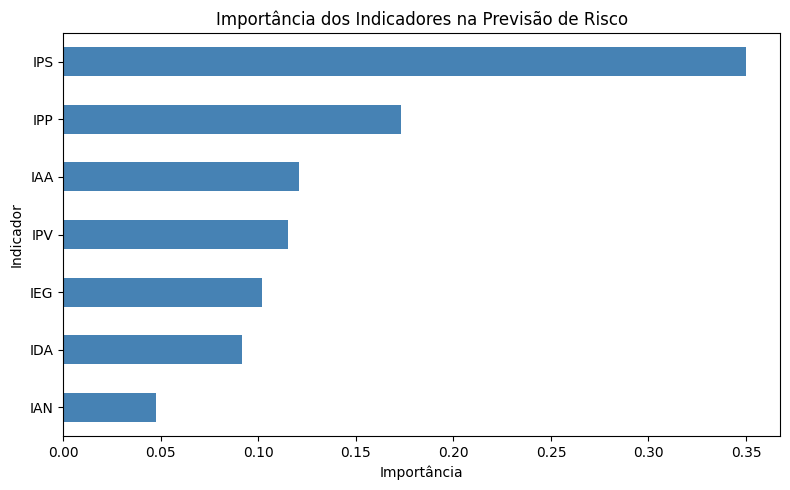

In [23]:
# Importância dos indicadores (quais padrões importam)
importancias = importancias.sort_values(ascending=True)
plt.figure(figsize=(8,5))
importancias.tail(30).plot(kind="barh", color="steelblue")
plt.title("Importância dos Indicadores na Previsão de Risco")
plt.xlabel("Importância")
plt.ylabel("Indicador")
plt.tight_layout()
plt.show()

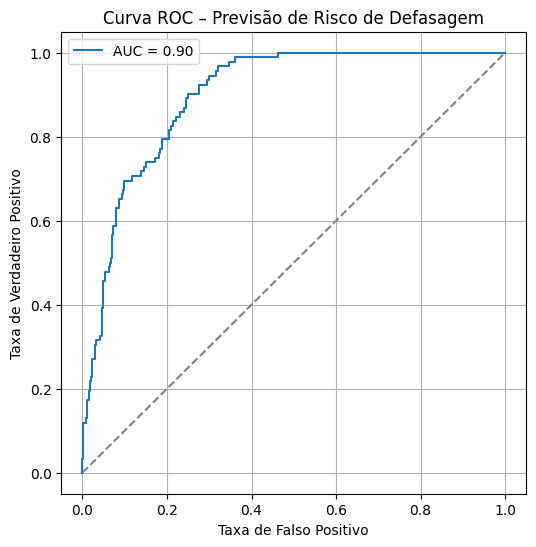

In [24]:
# Curva ROC – qualidade do modelo
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.title("Curva ROC – Previsão de Risco de Defasagem")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Probabilidade de risco por aluno
df_resultado = X_test.copy()

# Adiciona o RA
df_resultado["RA"] = df_model.loc[X_test.index, "RA"]

# Adiciona as demais informações
df_resultado["PROBALIDADE_RISCO"] = y_proba
df_resultado["RISCO_REAL"] = y_test.values

# --- Reordenar colunas: RA primeiro ---
colunas = ["RA"] + [col for col in df_resultado.columns if col != "RA"]
df_resultado = df_resultado[colunas]

# Exibir top 10
df_resultado.sort_values("PROBALIDADE_RISCO", ascending=False).head(10)

,RA,IAA,IEG,IPS,IDA,IPP,IPV,IAN,PROBALIDADE_RISCO,RISCO_REAL
1790,RA-921,9.0,9.7,7.52,6.3,5.6250,6.6800,10.0,0.823637,1
1869,RA-995,9.5,7.9,3.77,5.1,6.2500,7.1800,5.0,0.807907,1
1662,RA-787,9.0,9.8,7.52,5.9,5.6250,8.3400,5.0,0.794070,1
1715,RA-853,10.0,9.5,3.77,7.4,6.2500,9.8400,5.0,0.781696,0
1753,RA-888,9.0,10.0,7.52,8.8,7.5000,8.8300,10.0,0.772176,1
1106,RA-123,0.0,9.4,5.00,5.7,6.8750,6.8375,5.0,0.764624,1
1679,RA-805,0.0,9.1,7.52,6.8,6.2500,7.1750,5.0,0.760357,1
1709,RA-842,9.0,8.5,3.77,7.9,5.6250,8.0100,5.0,0.753111,1
1779,RA-911,9.0,6.7,2.52,3.4,5.3125,7.0100,5.0,0.748747,1
1178,RA-164,0.0,8.2,2.52,5.8,6.8750,6.9625,5.0,0.728250,1
